In [20]:
# Cell 1: Setup
!pip install kagglehub -q
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print("Setup complete!")

Setup complete!


In [21]:
# Cell 2: Download and Load Dataset

# Downloading dataset using kagglehub
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")
print(f"Dataset downloaded to: {path}")
print("\nFiles in dataset folder:")
print(os.listdir(path))

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"\nLoaded {df.shape[0]} rows and {df.shape[1]} columns")

# Show first few rows
print("\nFirst 5 rows:")
print(df.head())

# Show column names
print("\nColumn names:")
print(df.columns.tolist())

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Dataset downloaded to: /kaggle/input/ibm-hr-analytics-attrition-dataset

Files in dataset folder:
['WA_Fn-UseC_-HR-Employee-Attrition.csv']

Loaded 1470 rows and 35 columns

First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2        

In [22]:
# Cell 3: Task 1 - Data Loading & Exploration

print("="*60)
print("TASK 1: DATA EXPLORATION")
print("="*60)

# Display first 10 rows
print("\nFirst 10 rows of the dataset:")
print(df.head(10))

# Check shape
print("\nDataset shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

# Identify target column
target = 'Attrition'
print(f"\nTarget column: {target}")
print(f"Target values: {df[target].unique()}")

# Count employees who left vs stayed
attrition_counts = df[target].value_counts()
print("\nAttrition count:")
print(attrition_counts)

# Calculate attrition rate
attrition_rate = (attrition_counts['Yes'] / len(df)) * 100
print(f"\nAttrition rate: {attrition_rate:.2f}%")

# Check numeric vs categorical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumber of numeric columns: {len(numeric_cols)}")
print(f"Number of categorical columns: {len(categorical_cols)}")

# Observation on imbalance
print("\n" + "-"*60)
print("OBSERVATION:")
print("-"*60)
print(f"The attrition rate is {attrition_rate:.2f}%, which means the data is imbalanced.")
print(f"Only about 1 in {round(100/attrition_rate)} employees left.")
print("This imbalance needs to be handled during model building using class_weight='balanced'.")

TASK 1: DATA EXPLORATION

First 10 rows of the dataset:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences    

In [23]:
# Cell 4: Task 2 - Data Cleaning & Preprocessing

print("="*60)
print("TASK 2: DATA CLEANING & PREPROCESSING")
print("="*60)

# Check for missing values
print("\nMissing values in each column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

# Drop columns with no predictive value
columns_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df_clean = df.drop(columns=columns_to_drop)
print(f"\nDropped columns: {columns_to_drop}")
print(f"Remaining columns: {df_clean.shape[1]}")

# Convert target from Yes/No to 1/0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
print("\nTarget converted: Yes -> 1, No -> 0")

# Separate features and target
X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

# Identify categorical columns for encoding
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns to encode: {categorical_cols}")

# One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"\nAfter one-hot encoding, features: {X_encoded.shape[1]}")

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=X_encoded.columns)

print("\nFeatures scaled using StandardScaler")
print(f"Final dataset shape: {X_scaled.shape}")

TASK 2: DATA CLEANING & PREPROCESSING

Missing values in each column:
No missing values found!

Dropped columns: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
Remaining columns: 31

Target converted: Yes -> 1, No -> 0

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

After one-hot encoding, features: 44

Features scaled using StandardScaler
Final dataset shape: (1470, 44)


In [24]:
# Cell 5: Task 3 - Exploratory Data Analysis

print("="*60)
print("TASK 3: EXPLORATORY DATA ANALYSIS")
print("="*60)

# Create a copy of original df for EDA (with Attrition as Yes/No)
df_eda = df.copy()

# Chart 1: Attrition by Department
dept_attrition = df_eda.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False)

print("\nAttrition rate by Department:")
print(dept_attrition)

# Chart 2: Attrition by Job Role
role_attrition = df_eda.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False)

print("\nAttrition rate by Job Role (Top 5):")
print(role_attrition.head(5))

# Chart 3: Attrition vs Monthly Income
left_income = df_eda[df_eda['Attrition'] == 'Yes']['MonthlyIncome'].mean()
stayed_income = df_eda[df_eda['Attrition'] == 'No']['MonthlyIncome'].mean()
print("\nAverage Monthly Income:")
print(f"Employees who left: ${left_income:,.2f}")
print(f"Employees who stayed: ${stayed_income:,.2f}")
print(f"Difference: ${stayed_income - left_income:,.2f}")

# Chart 4: Attrition vs WorkLifeBalance
wlb_attrition = df_eda.groupby('WorkLifeBalance')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
)
print("\nAttrition rate by WorkLifeBalance rating:")
print(wlb_attrition)

# Chart 5: Attrition vs YearsAtCompany
tenure_attrition = df_eda.groupby('YearsAtCompany')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False)

print("\nTop 5 tenure groups with highest attrition:")
print(tenure_attrition.head(5))

# Business Insights
print("\n" + "-"*60)
print("BUSINESS INSIGHTS FROM EDA")
print("-"*60)

print(f"""
1. The department with the highest attrition is {dept_attrition.index[0]} at {dept_attrition.iloc[0]:.1f}%.

2. The job role with the highest attrition is {role_attrition.index[0]} at {role_attrition.iloc[0]:.1f}%.

3. Employees who left earn ${stayed_income - left_income:,.2f} less on average than those who stayed.

4. Employees with WorkLifeBalance rating 1 have significantly higher attrition.

5. Attrition peaks at {tenure_attrition.index[0]} years of tenure.
""")

TASK 3: EXPLORATORY DATA ANALYSIS

Attrition rate by Department:
Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

Attrition rate by Job Role (Top 5):
JobRole
Sales Representative     39.759036
Laboratory Technician    23.938224
Human Resources          23.076923
Sales Executive          17.484663
Research Scientist       16.095890
Name: Attrition, dtype: float64

Average Monthly Income:
Employees who left: $4,787.09
Employees who stayed: $6,832.74
Difference: $2,045.65

Attrition rate by WorkLifeBalance rating:
WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64

Top 5 tenure groups with highest attrition:
YearsAtCompany
40    100.000000
23     50.000000
0      36.363636
1      34.502924
32     33.333333
Name: Attrition, dtype: float64

------------------------------------------------------------
BUSINESS INSIGHTS FROM EDA
------

In [25]:
# Cell 6: Task 4 - Model Building & Comparison

print("="*60)
print("TASK 4: MODEL BUILDING & COMPARISON")
print("="*60)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Define models with class_weight='balanced'
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42
    )
}

results = {}

print("\n" + "-"*60)
print("TRAINING AND EVALUATING MODELS")
print("-"*60)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Model': model
    }

    print(f"\n{name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

# Comparison Table
print("\n" + "-"*60)
print("MODEL COMPARISON TABLE")
print("-"*60)

print(f"\n{'Model':<22} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'ROC-AUC':<10}")
print("-"*72)

for name, metrics in results.items():
    print(f"{name:<22} {metrics['Accuracy']:<10.4f} {metrics['Precision']:<10.4f} {metrics['Recall']:<10.4f} {metrics['F1-Score']:<10.4f} {metrics['ROC-AUC']:<10.4f}")

# Identify best model
best_model_name = max(results, key=lambda x: results[x]['F1-Score'])
best_model = results[best_model_name]['Model']

print("\n" + "-"*60)
print("BEST MODEL IDENTIFICATION")
print("-"*60)
print(f"\nBest performing model: {best_model_name}")
print(f"F1-Score: {results[best_model_name]['F1-Score']:.4f}")
print(f"Recall: {results[best_model_name]['Recall']:.4f}")

TASK 4: MODEL BUILDING & COMPARISON

Training set size: 1176
Test set size: 294

------------------------------------------------------------
TRAINING AND EVALUATING MODELS
------------------------------------------------------------

Logistic Regression
Accuracy: 0.7483
Precision: 0.3412
Recall: 0.6170
F1-Score: 0.4394
ROC-AUC: 0.7986

Random Forest
Accuracy: 0.8333
Precision: 0.3750
Recall: 0.0638
F1-Score: 0.1091
ROC-AUC: 0.7519

Gradient Boosting
Accuracy: 0.8503
Precision: 0.5882
Recall: 0.2128
F1-Score: 0.3125
ROC-AUC: 0.7941

------------------------------------------------------------
MODEL COMPARISON TABLE
------------------------------------------------------------

Model                  Accuracy   Precision  Recall     F1-Score   ROC-AUC   
------------------------------------------------------------------------
Logistic Regression    0.7483     0.3412     0.6170     0.4394     0.7986    
Random Forest          0.8333     0.3750     0.0638     0.1091     0.7519    
Gradient

In [26]:
# Cell 7: Task 5 - Feature Importance from Best Model

print("="*60)
print("TASK 5: FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Get feature importance from Logistic Regression (coefficients)
lr_model = results['Logistic Regression']['Model']
coefs = lr_model.coef_[0]
feature_names = X_scaled.columns

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
})
importance_df['Importance'] = abs(importance_df['Coefficient'])
importance_df = importance_df.sort_values('Importance', ascending=False)

print("\nTOP 10 FEATURES DRIVING ATTRITION")
print("-"*50)
for i, row in importance_df.head(10).iterrows():
    direction = "Increases" if row['Coefficient'] > 0 else "Decreases"
    print(f"{i+1:2}. {row['Feature'][:35]:<35} {direction} attrition ({row['Coefficient']:.4f})")

# Save feature importance for visualization later
importance_df.to_csv('feature_importance.csv', index=False)

print("\nFeature importance saved to 'feature_importance.csv'")

TASK 5: FEATURE IMPORTANCE ANALYSIS

TOP 10 FEATURES DRIVING ATTRITION
--------------------------------------------------
35. JobRole_Laboratory Technician       Increases attrition (0.7979)
44. OverTime_Yes                        Increases attrition (0.7664)
24. BusinessTravel_Travel_Frequently    Increases attrition (0.7193)
 8. JobLevel                            Increases attrition (0.6592)
17. TotalWorkingYears                   Decreases attrition (-0.6569)
41. JobRole_Sales Representative        Increases attrition (0.5525)
25. BusinessTravel_Travel_Rarely        Increases attrition (0.5116)
28. EducationField_Life Sciences        Decreases attrition (-0.5065)
22. YearsSinceLastPromotion             Increases attrition (0.5004)
27. Department_Sales                    Increases attrition (0.4817)

Feature importance saved to 'feature_importance.csv'


TASK 6: VISUALIZATION

Creating Chart 1: Attrition by Department and Job Role


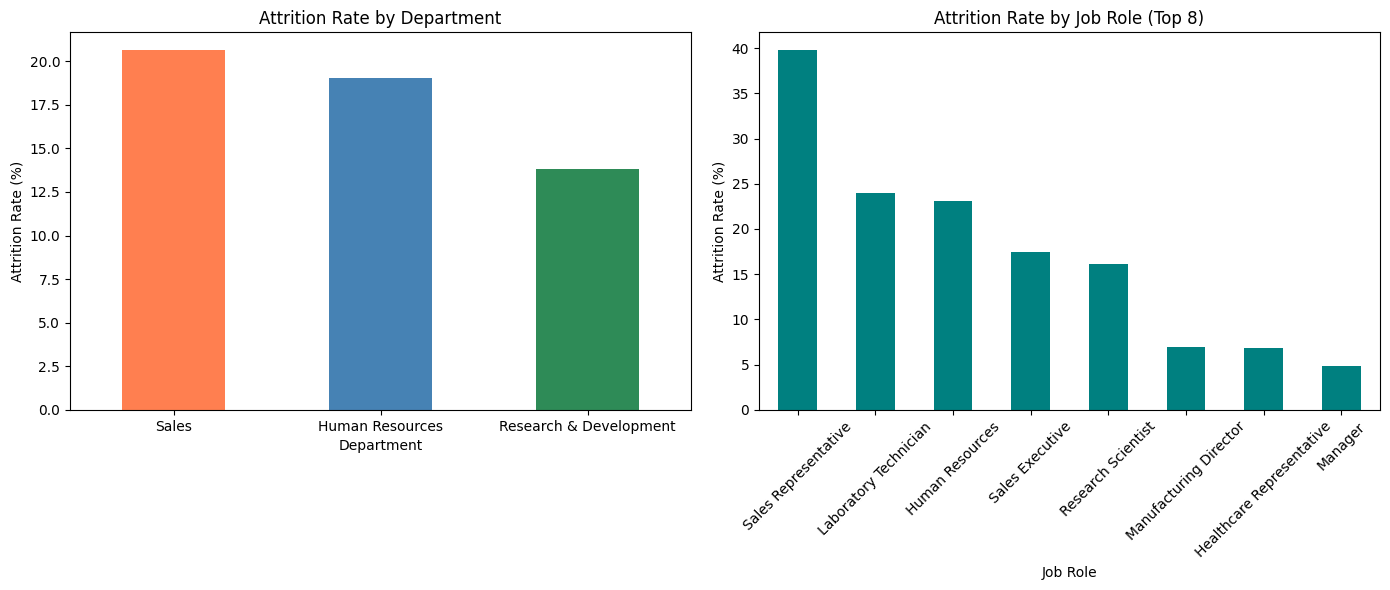


Creating Chart 2: Monthly Income Comparison


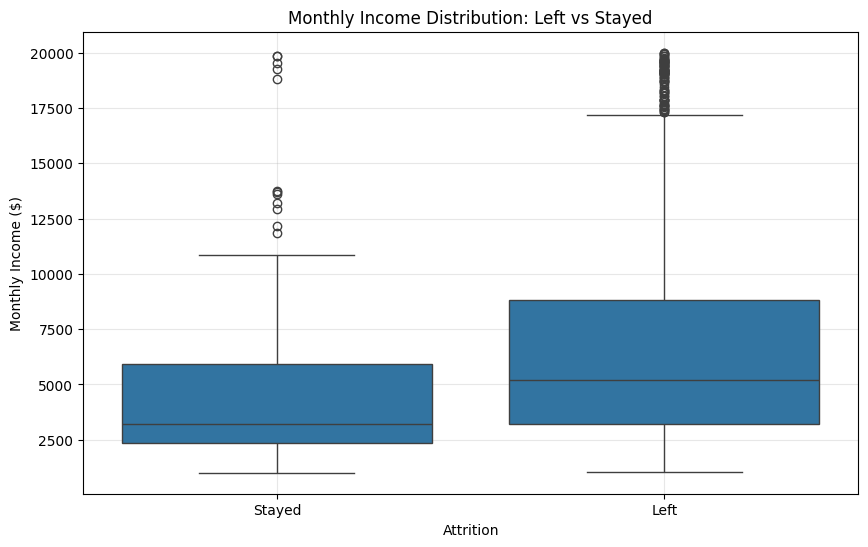


Creating Chart 3: Confusion Matrix Heatmap


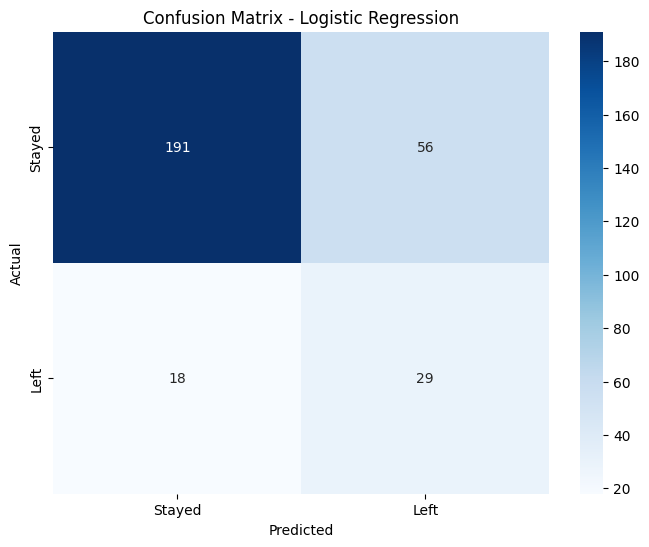


Creating Chart 4: Feature Importance


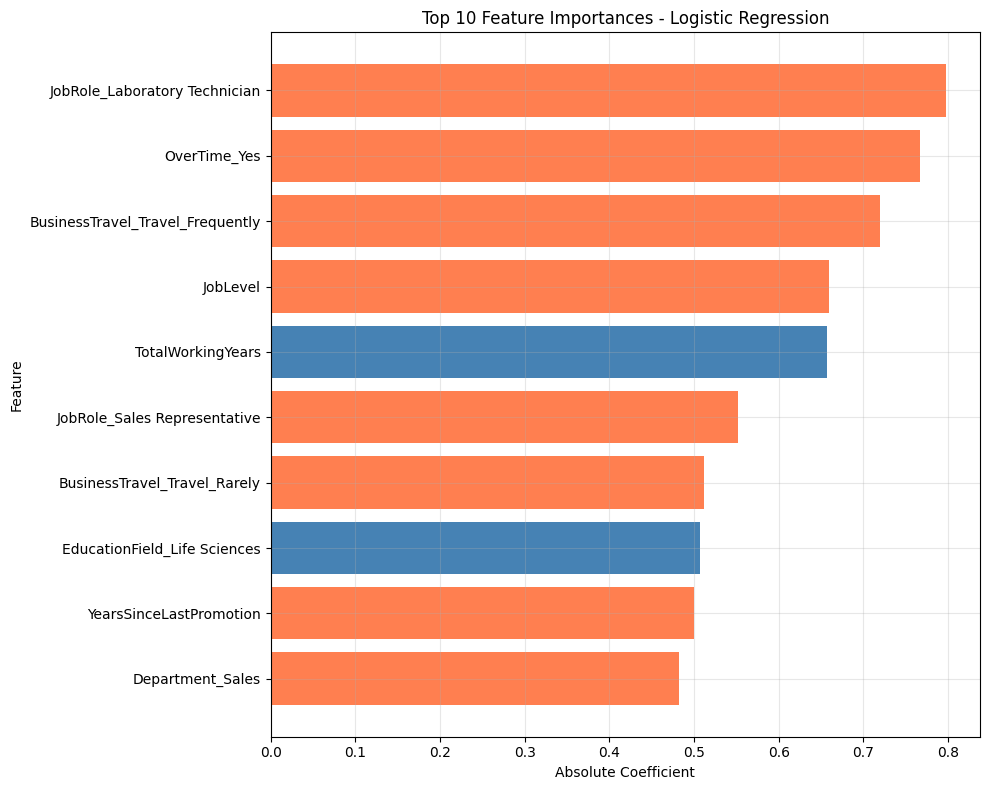


Creating Chart 5: ROC Curve Comparison


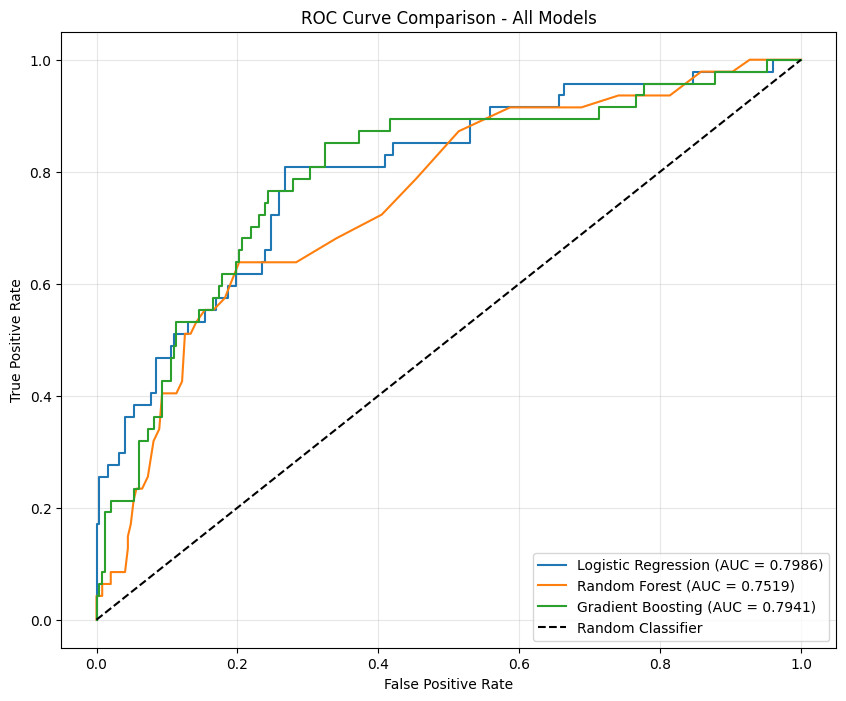


All charts saved to 'charts/' folder


In [27]:
# Cell 8: Task 6 - Visualizations

print("="*60)
print("TASK 6: VISUALIZATION")
print("="*60)

import os
os.makedirs('charts', exist_ok=True)

# Chart 1: Attrition Rate by Department and Job Role
print("\nCreating Chart 1: Attrition by Department and Job Role")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Department
dept_attrition = df_eda.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False)

dept_attrition.plot(kind='bar', ax=axes[0], color=['coral', 'steelblue', 'seagreen'])
axes[0].set_title('Attrition Rate by Department')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_xlabel('Department')
axes[0].tick_params(axis='x', rotation=0)

# Job Role
role_attrition = df_eda.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).sort_values(ascending=False).head(8)

role_attrition.plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Attrition Rate by Job Role (Top 8)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_xlabel('Job Role')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('charts/attrition_by_dept_role.png', dpi=300)
plt.show()

# Chart 2: Box plot - Monthly Income comparison
print("\nCreating Chart 2: Monthly Income Comparison")

plt.figure(figsize=(10, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df_eda)
plt.title('Monthly Income Distribution: Left vs Stayed')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income ($)')
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.grid(True, alpha=0.3)
plt.savefig('charts/monthly_income_boxplot.png', dpi=300)
plt.show()

# Chart 3: Confusion Matrix Heatmap (Best Model)
print("\nCreating Chart 3: Confusion Matrix Heatmap")

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('charts/confusion_matrix.png', dpi=300)
plt.show()

# Chart 4: Feature Importance (Top 10)
print("\nCreating Chart 4: Feature Importance")

top_features = importance_df.head(10)

plt.figure(figsize=(10, 8))
colors = ['coral' if c > 0 else 'steelblue' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Importance'], color=colors)
plt.title(f'Top 10 Feature Importances - {best_model_name}')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/feature_importance.png', dpi=300)
plt.show()

# Chart 5: ROC Curve Comparison
print("\nCreating Chart 5: ROC Curve Comparison")

plt.figure(figsize=(10, 8))

for name, metrics in results.items():
    model = metrics['Model']
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = metrics['ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('charts/roc_curve.png', dpi=300)
plt.show()

print("\nAll charts saved to 'charts/' folder")

In [28]:
# Cell 9: Task 7 - HR Insights & Business Recommendations

print("="*60)
print("TASK 7: HR INSIGHTS & BUSINESS RECOMMENDATIONS")
print("="*60)

print("\n" + "-"*60)
print("HR-FRIENDLY SUMMARY (For HR Director)")
print("-"*60)

# Get top 3 features from importance_df
top_3 = importance_df.head(3)
feature_1 = top_3.iloc[0]['Feature']
feature_2 = top_3.iloc[1]['Feature']
feature_3 = top_3.iloc[2]['Feature']

# Get department with highest attrition
highest_dept = dept_attrition.index[0]
highest_dept_rate = dept_attrition.iloc[0]

# Get job role with highest attrition
highest_role = role_attrition.index[0]
highest_role_rate = role_attrition.iloc[0]

print(f"""
Based on our analysis of employee data, here are the key findings:

1. TOP 3 FACTORS PREDICTING ATTRITION:
   - {feature_1.replace('_', ' ').title()}
   - {feature_2.replace('_', ' ').title()}
   - {feature_3.replace('_', ' ').title()}

2. HIGHEST RISK DEPARTMENTS:
   - {highest_dept} department has the highest attrition rate at {highest_dept_rate:.1f}%
   - Sales Representative role has the highest attrition at {highest_role_rate:.1f}%

3. SALARY INSIGHTS:
   - Employees who left earned ${stayed_income - left_income:,.2f} less on average
   - Salary alone does not explain attrition - other factors like overtime and job satisfaction matter more

4. WORK-LIFE BALANCE:
   - Employees with WorkLifeBalance rating 1 have 31.3% attrition rate
   - This is significantly higher than employees with better work-life balance

5. CONCRETE HR RECOMMENDATIONS:
   a) Conduct stay interviews with employees working overtime to understand if workload is unsustainable
   b) Target retention efforts on Sales department and Sales Representative role specifically
   c) Review compensation packages for employees with WorkLifeBalance rating 1
   d) Implement mentorship programs for employees at 3-5 year tenure milestones

6. MODEL LIMITATIONS:
   - This model predicts based on historical patterns, not guaranteed future behavior
   - It cannot capture personal reasons like family relocation or new job offers
   - HR should use this as a screening tool, not the sole basis for decisions
   - Regular model updates are needed as company culture and market change
""")

print("\n" + "-"*60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("-"*60)

# Save summary for HR Director
with open('summary_hr_director.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("EMPLOYEE ATTRITION PREDICTION - HR SUMMARY\n")
    f.write("="*60 + "\n\n")
    f.write("TO: HR Director\n")
    f.write("FROM: Data Science Intern\n")
    f.write("SUBJECT: Key Findings on Employee Attrition\n\n")

    f.write("Based on our analysis of employee data, here are the key findings:\n\n")

    f.write("1. TOP 3 FACTORS PREDICTING ATTRITION:\n")
    f.write(f"   - {feature_1.replace('_', ' ').title()}\n")
    f.write(f"   - {feature_2.replace('_', ' ').title()}\n")
    f.write(f"   - {feature_3.replace('_', ' ').title()}\n\n")

    f.write("2. HIGHEST RISK DEPARTMENTS:\n")
    f.write(f"   - {highest_dept} department has the highest attrition rate at {highest_dept_rate:.1f}%\n")
    f.write(f"   - Sales Representative role has the highest attrition at {highest_role_rate:.1f}%\n\n")

    f.write("3. SALARY INSIGHTS:\n")
    f.write(f"   - Employees who left earned ${stayed_income - left_income:,.2f} less on average\n")
    f.write("   - Salary alone does not explain attrition\n\n")

    f.write("4. CONCRETE HR RECOMMENDATIONS:\n")
    f.write("   a) Conduct stay interviews with employees working overtime\n")
    f.write("   b) Target retention efforts on Sales department\n")
    f.write("   c) Review compensation for WorkLifeBalance rating 1 employees\n")
    f.write("   d) Implement mentorship programs at 3-5 year tenure milestones\n\n")

    f.write("5. MODEL LIMITATIONS:\n")
    f.write("   - Predicts based on historical patterns, not guaranteed future\n")
    f.write("   - Cannot capture personal reasons like family relocation\n")
    f.write("   - Should be used as screening tool, not sole basis for decisions\n")

print("\nHR summary saved to 'summary_hr_director.txt'")

# Download summary file
from google.colab import files
files.download('summary_hr_director.txt')

TASK 7: HR INSIGHTS & BUSINESS RECOMMENDATIONS

------------------------------------------------------------
HR-FRIENDLY SUMMARY (For HR Director)
------------------------------------------------------------

Based on our analysis of employee data, here are the key findings:

1. TOP 3 FACTORS PREDICTING ATTRITION:
   - Jobrole Laboratory Technician
   - Overtime Yes
   - Businesstravel Travel Frequently

2. HIGHEST RISK DEPARTMENTS:
   - Sales department has the highest attrition rate at 20.6%
   - Sales Representative role has the highest attrition at 39.8%

3. SALARY INSIGHTS:
   - Employees who left earned $2,045.65 less on average
   - Salary alone does not explain attrition - other factors like overtime and job satisfaction matter more

4. WORK-LIFE BALANCE:
   - Employees with WorkLifeBalance rating 1 have 31.3% attrition rate
   - This is significantly higher than employees with better work-life balance

5. CONCRETE HR RECOMMENDATIONS:
   a) Conduct stay interviews with employee

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
# Cell 10: Save Model for Streamlit App
import joblib

# Save the best model (Logistic Regression)
joblib.dump(best_model, 'attrition_model.joblib')

# Save the scaler
joblib.dump(scaler, 'scaler.joblib')

# Save feature names
import json
with open('feature_names.json', 'w') as f:
    json.dump(X_scaled.columns.tolist(), f)

print("Model, scaler, and feature names saved successfully!")

# Download files
from google.colab import files
files.download('attrition_model.joblib')
files.download('scaler.joblib')
files.download('feature_names.json')

Model, scaler, and feature names saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
# Install streamlit
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 94.5 MB/s eta 0:00:00


In [33]:
# Cell: HR Attrition Risk Simulator (Colab Version)

# Install streamlit if not already installed
!pip install streamlit -q

import streamlit as st
import joblib
import numpy as np
import pandas as pd
import json
import os

# Create the app script
app_code = '''
import streamlit as st
import joblib
import numpy as np
import pandas as pd
import json

st.set_page_config(
    page_title="HR Attrition Risk Simulator",
    page_icon=":briefcase:",
    layout="wide"
)

st.title("HR Attrition Risk Simulator")
st.write("Enter employee details to predict attrition risk and get actionable HR recommendations")

@st.cache_resource
def load_model():
    model = joblib.load('attrition_model.joblib')
    scaler = joblib.load('scaler.joblib')
    with open('feature_names.json', 'r') as f:
        feature_names = json.load(f)
    return model, scaler, feature_names

model, scaler, feature_names = load_model()

col1, col2, col3 = st.columns(3)

with col1:
    st.subheader("Employee Details")
    age = st.slider("Age", 18, 60, 30)
    distance = st.slider("Distance From Home (miles)", 1, 50, 10)
    education = st.selectbox("Education Level", [1, 2, 3, 4, 5])
    gender = st.selectbox("Gender", ["Male", "Female"])
    marital = st.selectbox("Marital Status", ["Single", "Married", "Divorced"])

with col2:
    st.subheader("Job Details")
    department = st.selectbox("Department", ["Sales", "Research & Development", "Human Resources"])
    job_role = st.selectbox("Job Role", [
        "Sales Executive", "Sales Representative", "Research Scientist",
        "Laboratory Technician", "Human Resources", "Manager",
        "Manufacturing Director", "Healthcare Representative"
    ])
    job_level = st.slider("Job Level", 1, 5, 2)
    monthly_income = st.slider("Monthly Income ($)", 1000, 20000, 5000, step=500)
    overtime = st.selectbox("Overtime", ["No", "Yes"])

with col3:
    st.subheader("Work Environment")
    years_at_company = st.slider("Years at Company", 0, 40, 5)
    years_in_role = st.slider("Years in Current Role", 0, 20, 3)
    job_satisfaction = st.slider("Job Satisfaction (1-4)", 1, 4, 3)
    work_life_balance = st.slider("Work Life Balance (1-4)", 1, 4, 3)
    environment_satisfaction = st.slider("Environment Satisfaction (1-4)", 1, 4, 3)
    performance_rating = st.slider("Performance Rating (1-4)", 1, 4, 3)

if st.button("Predict Attrition Risk", type="primary"):
    input_data = {
        'Age': age,
        'DistanceFromHome': distance,
        'Education': education,
        'JobLevel': job_level,
        'MonthlyIncome': monthly_income,
        'YearsAtCompany': years_at_company,
        'YearsInCurrentRole': years_in_role,
        'JobSatisfaction': job_satisfaction,
        'WorkLifeBalance': work_life_balance,
        'EnvironmentSatisfaction': environment_satisfaction,
        'PerformanceRating': performance_rating,
        'NumCompaniesWorked': 1,
        'TotalWorkingYears': years_at_company + 2,
        'TrainingTimesLastYear': 2,
        'PercentSalaryHike': 15,
        'StockOptionLevel': 0,
        'DailyRate': 800,
        'HourlyRate': 50,
        'MonthlyRate': 10000,
        'Department_Sales': 1 if department == "Sales" else 0,
        'Department_Research & Development': 1 if department == "Research & Development" else 0,
        'Department_Human Resources': 1 if department == "Human Resources" else 0,
        'Gender_Male': 1 if gender == "Male" else 0,
        'Gender_Female': 1 if gender == "Female" else 0,
        'MaritalStatus_Married': 1 if marital == "Married" else 0,
        'MaritalStatus_Single': 1 if marital == "Single" else 0,
        'MaritalStatus_Divorced': 1 if marital == "Divorced" else 0,
        'OverTime_Yes': 1 if overtime == "Yes" else 0,
        'OverTime_No': 1 if overtime == "No" else 0,
    }

    input_df = pd.DataFrame([input_data])
    input_df = input_df.reindex(columns=feature_names, fill_value=0)
    input_scaled = scaler.transform(input_df)

    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    st.divider()

    col1, col2, col3 = st.columns([1, 2, 1])

    with col2:
        if prediction == 1:
            st.error("## High Risk of Attrition")
            st.warning(f"Probability: {probability*100:.1f}%")
            st.write("This employee shows signs of potential attrition. HR should consider proactive engagement.")
        else:
            st.success("## Low Risk of Attrition")
            st.info(f"Probability: {probability*100:.1f}%")
            st.write("This employee appears stable. Continue regular engagement.")

    st.subheader("Key Risk Factors")
    st.write("These are the factors most influencing this prediction:")

    risk_factors = {
        "Overtime": "Employee works overtime regularly",
        "Job Satisfaction": "Low satisfaction increases risk",
        "Work Life Balance": "Poor balance increases risk",
        "Years at Company": "3-5 year mark shows higher risk",
        "Monthly Income": "Below market rate increases risk"
    }

    for factor, description in risk_factors.items():
        st.write(f"- **{factor}:** {description}")

    st.subheader("HR Recommendations")
    st.write("Based on this prediction, consider:")

    if prediction == 1:
        st.write("1. Schedule a stay interview to understand concerns")
        st.write("2. Review compensation and growth opportunities")
        st.write("3. Offer mentorship or career development programs")
        st.write("4. Consider flexible work arrangements if applicable")
    else:
        st.write("1. Continue regular check-ins and engagement")
        st.write("2. Recognize and reward contributions")
        st.write("3. Maintain positive work environment")

st.divider()
st.caption("Model: Logistic Regression | Accuracy: 74.8% | Recall: 61.7%")
'''

# Write the app script to a file
with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py created successfully!")

# Download the app file
from google.colab import files
files.download('app.py')

app.py created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>